In [69]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import comb
from itertools import product

############
# parameters
############

N_arr = np.arange(2, 50, 2)
nmax = 100
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.1)

######################
# collective operators
######################

def collective_ops(N):
    sp, sm, I = qt.sigmap(), qt.sigmam(), qt.qeye(2)
    Sp = qt.jmat(N/2,'+')
    Sm = Sp.dag()
    Sz = qt.jmat(N/2,'z')
    HB = Sz+N/2*qt.qeye(N+1)
    return Sp, Sm, HB

############################
# Tavis-Cummings Hamiltonian
############################

def tavis_cummings(N, nmax, ω, ω0, g):
    a = qt.destroy(nmax)
    Sp, Sm, HB = collective_ops(N)
    IB = qt.qeye(N+1)
    H = ω * qt.tensor(a.dag()*a, IB) + ω0 * qt.tensor(qt.qeye(nmax), HB) + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm))

    return H, HB

################
# Passive state
################

def passive_state(rho, H):
    r_val, r_vec = rho.eigenstates()
    idx = np.argsort(r_val)[::-1]          # decending order
    r_val = r_val[idx]

    e_val, e_vec = H.eigenstates()          # ascending order

    return np.sum(r_val[i] * e_vec[i] * e_vec[i].dag()
               for i in range(len(r_val)))

    
########################
# ergotropy calculation
########################

def ergotropy(ρ, H):
    ρ_p = passive_state(ρ, H)
    return qt.expect(H, ρ) - qt.expect(H, ρ_p)


################
# Initial state
################

def initial_state(N, nmax, state):
    if state=="coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state=="fock":
        psiA = qt.basis(nmax, N)
    psiB = qt.basis(N+1, 0)  
    return qt.tensor(psiA, psiB)


##############
# Pnm matrix
##############

def pnm_matrix(rho, H):

    r_val, r_vec = rho.eigenstates()
    idx = np.argsort(r_val)[::-1]
    r_val = r_val[idx]
    r_vec = [r_vec[i] for i in idx]

    e_val, e_vec = H.eigenstates()

    pnm = np.zeros((len(e_val), len(e_val)))
    for n in range(len(e_val)):
        for m in range(len(e_val)):
            pnm[n, m] = r_val[m]*abs(e_vec[n].overlap(r_vec[m]))**2

    return pnm, r_val, e_val
    

############################
# ergotropy using pnm matrix
############################

def ergotropy_pnm(pnm, r_val, e_val):
    deltaE = e_val[:,None] - e_val[None,:]
    return np.sum(pnm * deltaE)


############################
# variance using pnm matrix
############################

def variance_pnm(pnm, r_val, e_val):
    deltaE2 = (e_val[:,None] - e_val[None,:])**2
    mean2 = np.sum(pnm * deltaE2)
    mean = ergotropy_pnm(pnm, r_val, e_val)
    return mean2 - mean**2

###########################
# Extracting Coefficients
###########################

def coefficients_dicke(rho_b, N):
    """
    Extract coefficients C_n corresponding to excitation number n = M + J.
    Works in computational basis.
    """
    # dim = rho_b.shape[0]
    diag = np.real(rho_b.diag())
    return diag[:N+1]
    # Cn = np.zeros(N+1)

    # # Loop over computational basis states
    # for idx, state in enumerate(product([0,1], repeat=N)):
    #     n_exc = sum(state)  # number of spins up = excitation number
    #     Cn[n_exc] += diag[idx]

    # return Cn


N= 2, τ=0.010, E_B=2.000
N= 4, τ=0.010, E_B=4.000
N= 6, τ=0.010, E_B=6.000
N= 8, τ=0.010, E_B=8.000
N=10, τ=0.010, E_B=10.000
N=12, τ=0.010, E_B=12.000
N=14, τ=0.010, E_B=14.000
N=16, τ=0.010, E_B=16.000
N=18, τ=0.010, E_B=18.000
N=20, τ=0.010, E_B=20.000
N=22, τ=0.010, E_B=22.000
N=24, τ=0.010, E_B=24.000
N=26, τ=0.010, E_B=26.000
N=28, τ=0.010, E_B=28.000
N=30, τ=0.010, E_B=30.000
N=32, τ=0.010, E_B=32.000
N=34, τ=0.010, E_B=34.000
N=36, τ=0.010, E_B=36.000
N=38, τ=0.010, E_B=38.000
N=40, τ=0.010, E_B=40.000
N=42, τ=0.010, E_B=42.000
N=44, τ=0.010, E_B=44.000
N=46, τ=0.010, E_B=46.000
N=48, τ=0.010, E_B=48.000


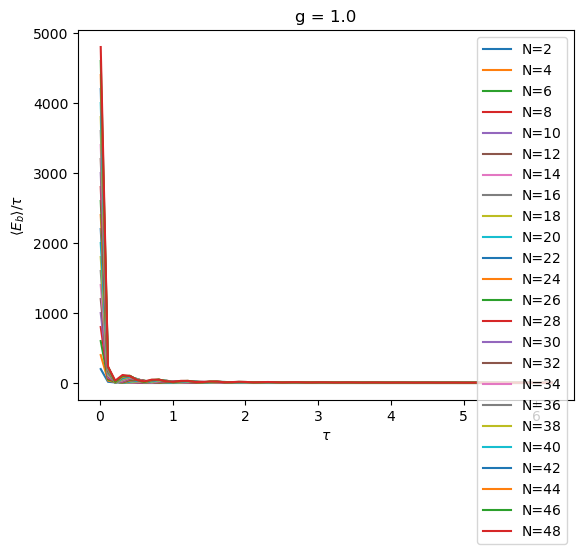

In [70]:

##############################################
# Plot Battery energy <Eb> as function of time 
# and pick time τ for which <Eb> is maximum
##############################################
τ_list = []

for N in N_arr:

    H, HB = tavis_cummings(N, nmax, ω, ω0, g)

    HB_full = qt.tensor(qt.qeye(nmax), HB)

    # Initial state
    ψ0 = initial_state(N, nmax, "coherent")

    # Time evolution
    result = qt.sesolve(H, ψ0, tlist, e_ops=HB_full)

    # Battery energy vs time
    Eb_list = np.array(result.expect[0])

    # Maximize charging power (Eb / t)
    power = Eb_list / tlist
    
    idx = np.argmax(power)
    
    τ = tlist[idx]
    
    τ_list.append(τ)

    print(f"N={N:2d}, τ={tlist[idx]:.3f}, E_B={Eb_list[idx]:.3f}")
    
    ##################################
    # Plot of battery energy with time
    ##################################
    
    plt.plot(tlist, power, label=f"N={N}")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle E_b \rangle / \tau$")
plt.legend()
plt.title(f"g = {g}")
plt.show()

In [71]:
# Eb_list = []
# erg_list = []
# var_list = []
# ratio_list = []


# for i, N in enumerate(N_arr):

#     τ = τ_list[i]

#     # Rebuild Hamiltonian
#     H, HB = tavis_cummings(N, nmax, ω, ω0, g)

#     # Initial state
#     ψ0 = initial_state(N, nmax, "coherent")

#     # Evolve until τ
#     result = qt.sesolve(H, ψ0, [0, τ])

#     # Full density matrix at τ
#     ρ_full = result.states[-1].proj()

#     # Partial trace over cavity (subsystem 0)
#     ρb = ρ_full.ptrace(1)

#     Eb = qt.expect(HB, ρb)

#     # Eigenvalues of HB
#     evals = HB.eigenenergies()

#     # Eigenvalues of rho_b (descending)
#     rho_eigs = np.sort(ρb.eigenenergies())[::-1]

#     # Get Cn and Cn^2
#     Cn = coefficients_dicke(ρb, N)
#     Cn_sq = Cn**2

#     # sqrt
#     sqrt_binom = np.array([np.sqrt(comb(N, n, exact=True)) for n in range(len(evals))])

#     Cn_factor = Cn_sq / sqrt_binom

#     for m in range(2):    # lowest two energy levels 
#         Em = evals[m]
#         rm = rho_eigs[m]
    
#         for n in range(len(evals)):
#             En = evals[n]
        
#             ΔE = Em - En

#             ΔE2 = (Em - En)**2
            
#             erg = np.sum(ΔE * rm * Cn_factor[n])

#             var = np.sum(ΔE2 * rm * Cn_sq[n])
        

#     ratio = erg/Eb

#     print(f"N={N:2d}, τ={τ:.3f}, Eb={Eb:.6f}, Ergotropy={erg:.6f}, erg/Eb={ratio:.12f} Variance={var:.10e}")

#     Eb_list.append(Eb)
#     erg_list.append(erg)
#     var_list.append(var)
#     ratio_list.append(ratio)

# Eb_arr = np.array(Eb_list)
# erg_arr = np.array(erg_list)
# var_arr = np.array(var_list)

# rel_fluct = np.sqrt(var_arr) / erg_arr

# rel_fluc = np.sqrt(var_arr) / Eb_arr

# ###############################################################
# # Plot of battery ergotropy at optimal charging for different N 
# ###############################################################

# plt.figure()
# plt.plot(N_arr, erg_list, 'o-', color='c')
# plt.xlabel(r"$N$")
# plt.ylabel(r"$\mathcal{E}_b$")
# plt.title("Battery ergotropy at optimal charging time")
# plt.show()

N= 2, τ=0.010, Eb=1.999400, Ergotropy=-0.000199, erg/Eb=-0.000099749585 Variance=2.0005307856e-04
N= 4, τ=0.010, Eb=3.998000, Ergotropy=-0.000396, erg/Eb=-0.000099073080 Variance=4.0206628273e-04
N= 6, τ=0.010, Eb=5.995800, Ergotropy=-0.000587, erg/Eb=-0.000097918042 Variance=6.1170045872e-04
N= 8, τ=0.010, Eb=7.992801, Ergotropy=-0.000769, erg/Eb=-0.000096232613 Variance=8.3820973937e-04
N=10, τ=0.010, Eb=9.989001, Ergotropy=-0.000939, erg/Eb=-0.000093979328 Variance=1.0941979655e-03
N=12, τ=0.010, Eb=11.984402, Ergotropy=-0.001092, erg/Eb=-0.000091132526 Variance=1.3953006903e-03
N=14, τ=0.010, Eb=13.979002, Ergotropy=-0.001226, erg/Eb=-0.000087677016 Variance=1.7598034270e-03
N=16, τ=0.010, Eb=15.972803, Ergotropy=-0.001335, erg/Eb=-0.000083607279 Variance=2.2082096378e-03
N=18, τ=0.010, Eb=17.965803, Ergotropy=-0.001418, erg/Eb=-0.000078926772 Variance=2.7627703488e-03
N=20, τ=0.010, Eb=19.958004, Ergotropy=-0.001470, erg/Eb=-0.000073647379 Variance=3.4469925992e-03
N=22, τ=0.010, 

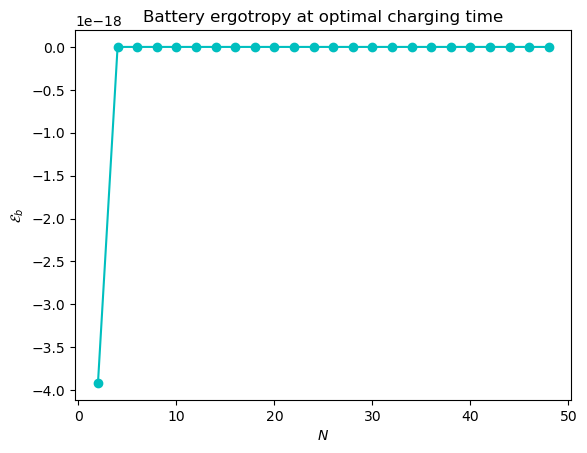

In [72]:
Eb_list = []

for i, N in enumerate(N_arr):

    τ = τ_list[i]

    # Rebuild Hamiltonian
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)

    # Initial state
    ψ0 = initial_state(N, nmax, "coherent")

    # Evolve until τ
    result = qt.sesolve(H, ψ0, [0, τ])

    # Full density matrix at τ
    ρ_full = result.states[-1].proj()

    # Partial trace over cavity (subsystem 0)
    ρb = ρ_full.ptrace(1)

    Eb = qt.expect(HB, ρb)

    # Eigenvalues of HB
    evals = HB.eigenenergies()

    # Eigenvalues of rho_b (descending)
    rho_eigs = np.sort(ρb.eigenenergies())[::-1]

    # Get Cn and Cn^2
    Cn = coefficients_dicke(ρb, N)
    Cn_sq = Cn**2

    # sqrt
    sqrt_binom = np.array([np.sqrt(comb(N, n, exact=True)) for n in range(len(evals))])

    Cn_factor = Cn_sq / sqrt_binom

    erg = 0
    var = 0

    for m in range(2):
        Em, rm = evals[m], rho_eigs[m]
        
        for n in range(len(evals)):
            ΔE = evals[n] - Em 
        
            erg += np.sum(ΔE * rm * Cn_factor[n])
            var += np.sum((ΔE**2) * rm * Cn_sq[n])

    ratio = erg/Eb

    print(f"N={N:2d}, τ={τ:.3f}, Eb={Eb:.6f}, Ergotropy={erg:.6f}, erg/Eb={ratio:.12f} Variance={var:.10e}")

Eb_arr = np.array(Eb_list)
erg_arr = np.array(erg)
var_arr = np.array(var)

rel_fluct = np.sqrt(var_arr) / erg_arr

rel_fluc = np.sqrt(var_arr) / Eb_arr

###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.figure()
plt.plot(N_arr, erg_list, 'o-', color='c')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
plt.show()

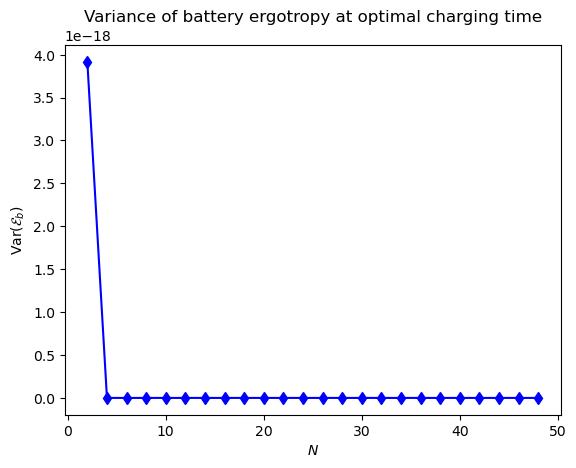

In [73]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, var_list, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
plt.show()

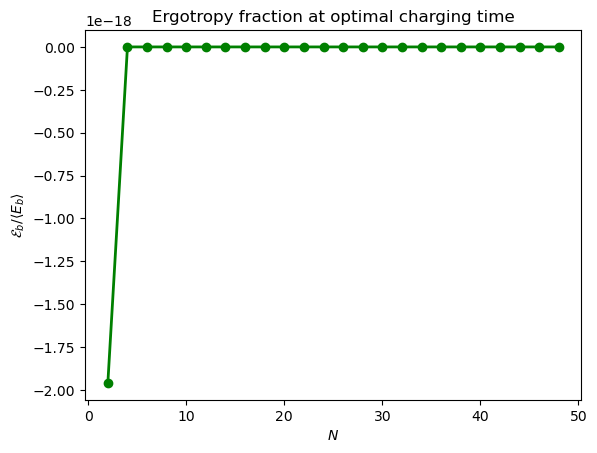

In [74]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
#############################################################


plt.figure()
plt.plot(N_arr, ratio_list, 'o-', color='g', linewidth=2)
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.title("Ergotropy fraction at optimal charging time")
plt.show()

In [75]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.3f}, "
          f"Relative Fluctuation ={rel_fluct:.12f}, "
          f"Relative Fluctuation with Eb ={rel_fluc:.12f}")

#######################################################################
# Plot fluctuations w.r.t ergotropy as a function of g for different N 
#######################################################################

plt.figure()
plt.plot(N_arr, rel_fluct, 's-', color='r')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations with $\mathcal{E}_b$")
plt.show()

TypeError: unsupported format string passed to numpy.ndarray.__format__

In [ ]:
############################################################################
# Plot fluctuations w.r.t battery energy as a function of g for different N 
############################################################################

plt.figure()
plt.plot(N_arr, rel_fluc, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
plt.show()